In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})
%matplotlib widget

In [2]:
# Paths
data_folder = os.path.abspath('../data')
figure_save_folder = os.path.abspath('../figures/CKII_pooled')
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Data folder: {data_folder}')
print(f'Figures will be saved to: {figure_save_folder}')

# ============================================================================
# CS+ PLACE CELL THRESHOLD (tunable parameter)
# ============================================================================
# A place cell is classified as CS+ if:
#   1. is_place_cell = True (based on All spikes spatial information)
#   2. Number of complex bursts inside the All-spikes place field during
#      locomotion (run_in from spike_shapes) >= CB_NUM_THRESHOLD
# CS- place cells are All spike place cells that don't meet the CS criterion
CB_NUM_THRESHOLD = 10  # Minimum number of CB inside PF during locomotion
print(f"\n{'='*70}")
print(f"CS+ PLC THRESHOLD: is_place_cell=True AND n_cb_in_pf >= {CB_NUM_THRESHOLD}")
print(f"  (CB counted during locomotion only, inside All-spikes PF)")
print(f"{'='*70}")

# ===================== GLOBAL PLOTTING PARAMETERS =====================
SMOOTH_WINDOW = 0
PLOT_TRIALS = True
TRIAL_ALPHA = 0.15
TRIAL_LINEWIDTH = 0.4
THETA_YLIM = (-0.05, 0.1)
SLOW_YLIM = (-0.1, 0.1)
FR_YLIM_SCALE = 1.2
SS_CS_YLIM_SCALE = 1.2
xlim = [-4,4]
MERGE_SS_CS = True
MERGE_PLATEAU = True
PLATEAU_VLIM = 0.01
trial_height = 0.05

print(f'\n=== Plotting Parameters ===')
print(f'Smoothing window: {SMOOTH_WINDOW} frames')
print(f'Plot individual trials: {PLOT_TRIALS}')
print(f'Trial alpha: {TRIAL_ALPHA}, linewidth: {TRIAL_LINEWIDTH}')
print(f'Theta ylim: {THETA_YLIM}, Slow ylim: {SLOW_YLIM}')
print(f'FR ylim scale: {FR_YLIM_SCALE}, SS/CS ylim scale: {SS_CS_YLIM_SCALE}')

ckii_folders = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
    'CKII_pAce47_PX_20260128',
    'CKII_pAce46_PR_20260222',
]

def get_deleted_cells(data_folder, folders, snr_threshold=3.5, bad_frac_threshold=0.9):
    deleted_set = set()
    for folder in folders:
        merged_path = os.path.join(data_folder, folder, 'merged_aligned_data_CS.pkl')
        if not os.path.exists(merged_path):
            continue
        with open(merged_path, 'rb') as f:
            merged_data = pickle.load(f)
        SNR_interpolated = merged_data.get('SNR_interpolated', [])
        for cell_idx in range(len(SNR_interpolated)):
            snr_vals = np.asarray(SNR_interpolated[cell_idx])
            if snr_vals.ndim == 0:
                deleted_set.add((folder, cell_idx))
                continue
            bad_mask = snr_vals < snr_threshold
            bad_frac = np.mean(bad_mask)
            if bad_frac > bad_frac_threshold:
                deleted_set.add((folder, cell_idx))
    return deleted_set

deleted_cells = get_deleted_cells(data_folder, ckii_folders)
print(f'Found {len(deleted_cells)} truly deleted cells (>90% bad SNR frames).')

# ============================================================================
# Count complex bursts inside place field during locomotion from spike_shapes
# (spike_shapes are saved per cell in spatial_analysis_full.pkl, computed
#  using the All-spikes place field mask; we use 'run_in' = locomotion + in PF)
# ============================================================================
cb_in_pf_counts = {}
for folder in ckii_folders:
    spatial_path = os.path.join(data_folder, folder, 'spatial_analysis_full.pkl')
    if not os.path.exists(spatial_path):
        print(f"  Missing spatial data: {spatial_path}")
        continue
    with open(spatial_path, 'rb') as f:
        spatial_cells = pickle.load(f)
    for cell in spatial_cells:
        cell_idx = cell['cell_idx']
        spike_shapes = cell.get('spike_shapes')
        if spike_shapes and 'complex' in spike_shapes:
            cb = spike_shapes['complex']['shapes']
            n_in = len(cb.get('run_in', []))
        else:
            n_in = 0
        cb_in_pf_counts[(folder, cell_idx)] = n_in

print(f"\nCB-in-PF counts loaded for {len(cb_in_pf_counts)} cells")

# Load pooled stats and filter deleted cells
all_dfs = []
for folder in ckii_folders:
    pkl_path = os.path.join(data_folder, folder, 'pooled_stats.pkl')
    if os.path.exists(pkl_path):
        df = pd.read_pickle(pkl_path)
        df['session'] = folder
        all_dfs.append(df)
        print(f'Loaded {len(df)} cells from {folder}')
    else:
        print(f'Missing: {pkl_path}')

if len(all_dfs) == 0:
    raise RuntimeError('No pooled_stats.pkl found.')

df_all_raw = pd.concat(all_dfs, ignore_index=True)
valid_mask = ~df_all_raw.apply(lambda row: (row['session'], row['cell_idx']) in deleted_cells, axis=1)
df_all = df_all_raw[valid_mask].copy().reset_index(drop=True)
df_pc = df_all[df_all['is_place_cell'] == True].copy()

# ========================================================================
# CS+ PLC classification: place cells with >= CB_NUM_THRESHOLD complex
# bursts inside the All-spikes place field during locomotion
# ========================================================================
n_cb_in_pf = df_pc.apply(
    lambda row: cb_in_pf_counts.get((row['session'], row['cell_idx']), 0),
    axis=1
).values

is_cs_plc = n_cb_in_pf >= CB_NUM_THRESHOLD

# Add the new classification columns
df_pc['is_cs_plc'] = is_cs_plc
df_pc['n_cb_in_pf'] = n_cb_in_pf

# Also update df_all for the place cells
df_all.loc[df_all['is_place_cell'] == True, 'is_cs_plc'] = False
df_all.loc[df_all['is_place_cell'] == True, 'n_cb_in_pf'] = 0
df_all.loc[df_pc.index, 'is_cs_plc'] = is_cs_plc
df_all.loc[df_pc.index, 'n_cb_in_pf'] = n_cb_in_pf

# Count CS+ and CS- place cells
n_cs_plus = is_cs_plc.sum()
n_cs_minus = (~is_cs_plc).sum()

print(f"\n{'='*70}")
print(f"CS+ / CS- PLACE CELL CLASSIFICATION")
print(f"  Threshold: n_cb_in_pf (locomotion) >= {CB_NUM_THRESHOLD}")
print(f"{'='*70}")
print(f"  CS+ PLCs: {n_cs_plus} ({100*n_cs_plus/len(df_pc):.1f}%) - PLCs with >= {CB_NUM_THRESHOLD} CB in PF")
print(f"  CS- PLCs: {n_cs_minus} ({100*n_cs_minus/len(df_pc):.1f}%) - PLCs with < {CB_NUM_THRESHOLD} CB in PF")
print(f"  (CB in PF: mean = {np.mean(n_cb_in_pf):.1f}, median = {np.median(n_cb_in_pf):.1f}, max = {np.max(n_cb_in_pf)})")

# Load pf_centered_trial_data
pf_centered_data_by_session = {}
time_rel_by_session = {}
center_by_pf_position_by_session = {}

for folder in ckii_folders:
    pkl_path = os.path.join(data_folder, folder, 'pf_centered_trial_data.pkl')
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            d = pickle.load(f)
        pf_centered_data_by_session[folder] = d.get('pf_centered_data', [])
        time_rel_by_session[folder] = np.asarray(d.get('time_rel', []), dtype=float)
        center_by_pf_position_by_session[folder] = d.get('center_by_pf_position', False)
        n_cells = len(pf_centered_data_by_session[folder])
        n_with_data = sum(1 for x in pf_centered_data_by_session[folder] if x is not None)
        print(f'Loaded pf_centered_trial_data from {folder}: {n_with_data}/{n_cells} cells with data')
    else:
        print(f'Missing: {pkl_path}')

# ===================== Helper functions =====================
def _fmt_two_decimals(x, _):
    return f"{x:.2f}".rstrip("0").rstrip(".")

def _smooth_boxcar(trace, win=5):
    arr = np.asarray(trace, dtype=float)
    if win <= 1:
        return arr
    kernel = np.ones(win, dtype=float)
    valid = np.isfinite(arr).astype(float)
    arr_filled = np.where(np.isfinite(arr), arr, 0.0)
    smoothed = np.convolve(arr_filled, kernel, mode="same")
    counts = np.convolve(valid, kernel, mode="same")
    with np.errstate(invalid="ignore", divide="ignore"):
        smoothed = np.where(counts > 0, smoothed / counts, np.nan)
    return smoothed

def collect_category_data(is_cs_plc_value):
    time_rel_ref = None
    entries = []
    for _, row in df_all[df_all['is_place_cell'] == True].iterrows():
        if bool(row.get('is_cs_plc', False)) != is_cs_plc_value:
            continue
        session = row['session']
        cell_idx = int(row['cell_idx'])
        pf_data_list = pf_centered_data_by_session.get(session, None)
        if pf_data_list is None or cell_idx >= len(pf_data_list):
            continue
        cell_data = pf_data_list[cell_idx]
        if cell_data is None:
            continue
        time_rel = time_rel_by_session.get(session, None)
        if time_rel is None or len(time_rel) == 0:
            continue
        if time_rel_ref is None:
            time_rel_ref = time_rel
        if len(time_rel_ref) != len(time_rel):
            continue
        entries.append({'session': session, 'cell_idx': cell_idx, 'data': cell_data})
    return time_rel_ref, entries

# ===================== Individual cell plotting =====================
def plot_single_cell_3col(entry_data, time_rel, smooth_window=100, plot_trials=True, 
                          trial_alpha=0.2, trial_linewidth=0.5, out_path=None, show_plot=True,
                          theta_ylim=None, slow_ylim=None, fr_ylim_scale=1.2, ss_cs_ylim_scale=1.2):
    cell_data = entry_data['data']
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    
    all_data = cell_data.get('all', {})
    cw_data = cell_data.get('cw', {})
    ccw_data = cell_data.get('ccw', {})
    
    def _prep_data(data, ref_time_rel, do_smooth=True):
        if data is None:
            return None
        data = np.asarray(data, dtype=float)
        if len(data) != len(ref_time_rel):
            return None
        if do_smooth:
            data = _smooth_boxcar(data, smooth_window)
        return data
    
    theta = _prep_data(all_data.get('theta_mean'), time_rel)
    slow = _prep_data(all_data.get('slow_mean'), time_rel)
    rate = _prep_data(all_data.get('rate_mean'), time_rel)
    ss_rate = _prep_data(all_data.get('ss_rate_mean'), time_rel)
    cs_rate = _prep_data(all_data.get('cs_rate_mean'), time_rel)
    
    theta_cw = _prep_data(cw_data.get('theta_mean'), time_rel)
    slow_cw = _prep_data(cw_data.get('slow_mean'), time_rel)
    rate_cw = _prep_data(cw_data.get('rate_mean'), time_rel)
    ss_rate_cw = _prep_data(cw_data.get('ss_rate_mean'), time_rel)
    cs_rate_cw = _prep_data(cw_data.get('cs_rate_mean'), time_rel)
    
    theta_ccw = _prep_data(ccw_data.get('theta_mean'), time_rel)
    slow_ccw = _prep_data(ccw_data.get('slow_mean'), time_rel)
    rate_ccw = _prep_data(ccw_data.get('rate_mean'), time_rel)
    ss_rate_ccw = _prep_data(ccw_data.get('ss_rate_mean'), time_rel)
    cs_rate_ccw = _prep_data(ccw_data.get('cs_rate_mean'), time_rel)
    
    n_valid_all = all_data.get('n_trials', 0)
    n_total_all = all_data.get('n_total_trials', 0)
    n_valid_cw = cw_data.get('n_trials', 0)
    n_total_cw = cw_data.get('n_total_trials', 0)
    n_valid_ccw = ccw_data.get('n_trials', 0)
    n_total_ccw = ccw_data.get('n_total_trials', 0)
    
    fr_max = 0
    for rt in [rate, rate_cw, rate_ccw]:
        if rt is not None:
            fr_max = max(fr_max, np.nanmax(rt))
    fr_ylim_auto = (0, fr_max * fr_ylim_scale) if fr_max > 0 else None
    
    ss_cs_max = 0
    for rt in [ss_rate, cs_rate, ss_rate_cw, cs_rate_cw, ss_rate_ccw, cs_rate_ccw]:
        if rt is not None:
            ss_cs_max = max(ss_cs_max, np.nanmax(rt))
    ss_cs_ylim_auto = (0, ss_cs_max * ss_cs_ylim_scale) if ss_cs_max > 0 else None
    
    fig1 = plt.figure(figsize=(6, 3.5))
    axes1 = np.empty((4, 3), dtype=object)
    for col in range(3):
        sharey_ax = axes1[3, 0] if col > 0 else None
        axes1[3, col] = fig1.add_subplot(4, 3, 3 * 3 + col + 1, sharey=sharey_ax)
    for row in range(3):
        for col in range(3):
            sharey_ax = axes1[row, 0] if col > 0 else None
            sharex_ax = axes1[3, col]
            axes1[row, col] = fig1.add_subplot(4, 3, row * 3 + col + 1, sharex=sharex_ax, sharey=sharey_ax)
    
    def _plot_fig1_column(axes_col, t_rel, th, sl, rt, ss_rt, cs_rt, dir_data, title_suffix, n_valid, n_total):
        if plot_trials and dir_data.get('n_trials', 0) > 0:
            n_trials = dir_data['n_trials']
            rate_stack = dir_data.get('rate_stack')
            ss_rate_stack = dir_data.get('ss_rate_stack')
            cs_rate_stack = dir_data.get('cs_rate_stack')
            theta_stack = dir_data.get('theta_stack')
            slow_stack = dir_data.get('slow_stack')
            for i in range(n_trials):
                if rate_stack is not None and i < len(rate_stack):
                    trial_rate = _smooth_boxcar(rate_stack[i], smooth_window)
                    axes_col[0].plot(t_rel, trial_rate, color='#555555', linewidth=trial_linewidth, alpha=trial_alpha)
                if ss_rate_stack is not None and cs_rate_stack is not None and i < len(ss_rate_stack):
                    trial_ss = _smooth_boxcar(ss_rate_stack[i], smooth_window)
                    trial_cs = _smooth_boxcar(cs_rate_stack[i], smooth_window)
                    axes_col[1].plot(t_rel, trial_cs, color='#EE9B00', linewidth=trial_linewidth, alpha=trial_alpha)
                    axes_col[1].plot(t_rel, trial_ss, color='#026C80', linewidth=trial_linewidth, alpha=trial_alpha)
                if theta_stack is not None and i < len(theta_stack):
                    trial_theta = _smooth_boxcar(theta_stack[i], smooth_window)
                    axes_col[2].plot(t_rel, trial_theta, color='blue', linewidth=trial_linewidth, alpha=trial_alpha)
                if slow_stack is not None and i < len(slow_stack):
                    trial_slow = _smooth_boxcar(slow_stack[i], smooth_window)
                    axes_col[3].plot(t_rel, trial_slow, color='red', linewidth=trial_linewidth, alpha=trial_alpha)
        if rt is not None:
            axes_col[0].plot(t_rel, rt, color='#555555', linewidth=1.0)
        axes_col[0].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if cs_rt is not None:
            axes_col[1].plot(t_rel, cs_rt, color='#EE9B00', linewidth=1.0)
        if ss_rt is not None:
            axes_col[1].plot(t_rel, ss_rt, color='#026C80', linewidth=1.0)
        axes_col[1].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if th is not None:
            axes_col[2].plot(t_rel, th, color='blue', linewidth=1.0)
        axes_col[2].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if sl is not None:
            axes_col[3].plot(t_rel, sl, color='red', linewidth=1.0)
        axes_col[3].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes_col[3].axhline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes_col[0].set_title(f'{title_suffix}\n({n_valid}/{n_total} valid)', fontsize=6)
    
    _plot_fig1_column(axes1[:, 0], time_rel, theta, slow, rate, ss_rate, cs_rate, all_data, "All", n_valid_all, n_total_all)
    _plot_fig1_column(axes1[:, 1], time_rel, theta_cw, slow_cw, rate_cw, ss_rate_cw, cs_rate_cw, cw_data, "CW", n_valid_cw, n_total_cw)
    _plot_fig1_column(axes1[:, 2], time_rel, theta_ccw, slow_ccw, rate_ccw, ss_rate_ccw, cs_rate_ccw, ccw_data, "CCW", n_valid_ccw, n_total_ccw)
    
    axes1[0, 0].set_ylabel('FR', fontsize=6)
    axes1[1, 0].set_ylabel('SS/CS FR', fontsize=6)
    axes1[2, 0].set_ylabel('θ amp.\n(spk. height)', fontsize=6)
    axes1[3, 0].set_ylabel('Slow Vm\n(spk. height)', fontsize=6)
    for col in range(3):
        axes1[3, col].set_xlabel('Time from max FR (s)', fontsize=6)
    for row in range(3):
        for col in range(3):
            axes1[row, col].tick_params(labelbottom=False)
    if fr_ylim_auto is not None:
        for col in range(3):
            axes1[0, col].set_ylim(fr_ylim_auto)
    if ss_cs_ylim_auto is not None:
        for col in range(3):
            axes1[1, col].set_ylim(ss_cs_ylim_auto)
    if theta_ylim is not None:
        for col in range(3):
            axes1[2, col].set_ylim(theta_ylim)
    if slow_ylim is not None:
        for col in range(3):
            axes1[3, col].set_ylim(slow_ylim)
    for ax in axes1.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=5)
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig1.suptitle(f'{session} - Cell {cell_idx + 1}', fontsize=8)
    
    fig2, axes2 = plt.subplots(2, 3, figsize=(6, 2.0), sharey='row')
    def _plot_trial_rates(ax_all, ax_sscs, dir_data, show_legend=False):
        trial_data = dir_data.get('trial_data', None)
        if trial_data is None:
            ax_all.text(0.5, 0.5, 'No trial_data', transform=ax_all.transAxes, ha='center', va='center', fontsize=6)
            ax_sscs.text(0.5, 0.5, 'No trial_data', transform=ax_sscs.transAxes, ha='center', va='center', fontsize=6)
            return
        x = np.asarray(trial_data.get('epoch_start_sec', []), dtype=float)
        fr_all = np.asarray(trial_data.get('fr_all_hz', []), dtype=float)
        fr_ss = np.asarray(trial_data.get('fr_ss_hz', []), dtype=float)
        fr_cs = np.asarray(trial_data.get('fr_cs_hz', []), dtype=float)
        if x.size == 0:
            ax_all.text(0.5, 0.5, 'No trials', transform=ax_all.transAxes, ha='center', va='center', fontsize=6)
            ax_sscs.text(0.5, 0.5, 'No trials', transform=ax_sscs.transAxes, ha='center', va='center', fontsize=6)
            return
        mask = np.isfinite(x) & np.isfinite(fr_all)
        if not np.any(mask):
            return
        xs = x[mask]
        order = np.argsort(xs)
        xs = xs[order]
        ya = fr_all[mask][order]
        yss = fr_ss[mask][order]
        ycs = fr_cs[mask][order]
        ax_all.plot(xs, ya, color='#555555', linewidth=0.6, marker='o', markersize=2.0, alpha=0.9)
        ax_sscs.plot(xs, ycs, color='#EE9B00', linewidth=0.6, marker='o', markersize=2.0, alpha=0.9, label='CS')
        ax_sscs.plot(xs, yss, color='#026C80', linewidth=0.6, marker='o', markersize=2.0, alpha=0.9, label='SS')
        if show_legend:
            ax_sscs.legend(fontsize=5, frameon=False, loc='upper right')
    _plot_trial_rates(axes2[0, 0], axes2[1, 0], all_data, show_legend=True)
    _plot_trial_rates(axes2[0, 1], axes2[1, 1], cw_data)
    _plot_trial_rates(axes2[0, 2], axes2[1, 2], ccw_data)
    axes2[0, 0].set_title('All', fontsize=6)
    axes2[0, 1].set_title('CW', fontsize=6)
    axes2[0, 2].set_title('CCW', fontsize=6)
    axes2[0, 0].set_ylabel('Trial FR\n(Hz)', fontsize=6)
    axes2[1, 0].set_ylabel('Trial SS/CS\nFR (Hz)', fontsize=6)
    for col in range(3):
        axes2[1, col].set_xlabel('Trial start time (s)', fontsize=6)
    for ax in axes2.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=5)
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_two_decimals))
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    fig2.suptitle(f'{session} - Cell {cell_idx + 1} (Trial rates)', fontsize=8)
    
    if out_path is not None:
        fig1.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
        base, ext = os.path.splitext(out_path)
        out_path2 = f'{base}_trials{ext}'
        fig2.savefig(out_path2, dpi=300)
        print(f'Saved: {out_path2}')
    if show_plot:
        plt.show()
    else:
        plt.close(fig1)
        plt.close(fig2)
    return fig1, fig2

# ===================== Pooled average plotting =====================
def _stack_metric_from_entries(entries, direction, key, n_time, smooth_window=None):
    arrs = []
    for e in entries:
        data = e.get('data')
        if data is None:
            continue
        dir_data = data.get(direction, {})
        if dir_data.get('n_trials', 0) == 0:
            continue
        arr = dir_data.get(key)
        if arr is None or np.asarray(arr).size == 0:
            continue
        arr = np.asarray(arr, dtype=float)
        if arr.ndim == 2:
            mean_arr = np.nanmean(arr, axis=0)
        else:
            mean_arr = arr
        if mean_arr.size != n_time:
            continue
        if smooth_window is not None and smooth_window > 1:
            mean_arr = _smooth_boxcar(mean_arr, smooth_window)
        arrs.append(mean_arr)
    if len(arrs) == 0:
        return None
    return np.vstack(arrs)

def plot_pooled_category_3col(time_rel, entries, title, out_path=None,
                               smooth_window=None, plot_trials=True,
                               trial_alpha=0.2, trial_linewidth=0.5,
                               theta_ylim=None, slow_ylim=None,
                               fr_ylim_scale=1.2, ss_cs_ylim_scale=1.2, figsize=(4,2.5), xlim=[-2,2]):
    if time_rel is None or len(entries) == 0:
        print(f'No data to plot for {title}')
        return
    n_time = len(time_rel)

    def _mean_sem(arr):
        if arr is None or arr.size == 0:
            return None, None
        mean = np.nanmean(arr, axis=0)
        sem = np.nanstd(arr, axis=0) / np.sqrt(arr.shape[0])
        return mean, sem

    def _extract_mean_trace(cell_data, direction, key):
        if cell_data is None:
            return None
        dir_data = cell_data.get(direction, {})
        arr = dir_data.get(key)
        if arr is None:
            return None
        arr = np.asarray(arr, dtype=float)
        if arr.ndim == 2:
            if arr.shape[1] != n_time:
                return None
            trace = np.nanmean(arr, axis=0)
        elif arr.ndim == 1:
            if arr.size != n_time:
                return None
            trace = arr
        else:
            return None
        if smooth_window is not None and smooth_window > 1:
            trace = _smooth_boxcar(trace, smooth_window)
        return trace

    zero_idx = np.argmin(np.abs(time_rel))
    metric_keys = ['rate_stack', 'ss_rate_stack', 'cs_rate_stack', 'theta_stack', 'slow_stack']
    records = []

    for e in entries:
        cell_data = e.get('data')
        if cell_data is None:
            continue

        traces = {'all': {}, 'cw': {}, 'ccw': {}}
        for base_dir in ['all', 'cw', 'ccw']:
            for key in metric_keys:
                traces[base_dir][key] = _extract_mean_trace(cell_data, base_dir, key)

        all_rate = traces['all']['rate_stack']
        cw_rate = traces['cw']['rate_stack']
        ccw_rate = traces['ccw']['rate_stack']

        all_zero = np.nan
        if all_rate is not None:
            all_zero = all_rate[zero_idx]

        preferred_dir = None
        if cw_rate is not None and ccw_rate is not None:
            cw_zero = cw_rate[zero_idx]
            ccw_zero = ccw_rate[zero_idx]
            if np.isfinite(cw_zero) and np.isfinite(ccw_zero):
                if cw_zero > ccw_zero:
                    preferred_dir = 'cw'
                elif ccw_zero > cw_zero:
                    preferred_dir = 'ccw'

        records.append({
            'traces': traces,
            'all_rate_zero': all_zero,
            'preferred_dir': preferred_dir,
        })

    def _collect_stack(column_key, metric_key, normalize_with_all=False):
        arrs = []
        for rec in records:
            if column_key == 'all':
                trace = rec['traces']['all'][metric_key]
            elif column_key == 'preferred':
                pref = rec['preferred_dir']
                if pref is None:
                    continue
                trace = rec['traces'][pref][metric_key]
            elif column_key == 'nonpreferred':
                pref = rec['preferred_dir']
                if pref is None:
                    continue
                nonpref = 'ccw' if pref == 'cw' else 'cw'
                trace = rec['traces'][nonpref][metric_key]
            else:
                continue

            if trace is None:
                continue
            trace = np.asarray(trace, dtype=float)
            if trace.size != n_time:
                continue

            if normalize_with_all:
                denom = rec['all_rate_zero']
                if (not np.isfinite(denom)) or denom == 0:
                    continue
                trace = trace / denom

            arrs.append(trace)

        if len(arrs) == 0:
            return None
        return np.vstack(arrs)

    fig, axes = plt.subplots(4, 3, figsize=figsize, sharex='all', sharey='row')
    directions = ['all', 'preferred', 'nonpreferred']
    dir_titles = ['All', 'Preferred', 'Non-preferred']

    all_rate_means = []
    all_ss_means = []
    all_cs_means = []

    for direction in directions:
        rate_norm = _collect_stack(direction, 'rate_stack', normalize_with_all=True)
        ss_rate_norm = _collect_stack(direction, 'ss_rate_stack', normalize_with_all=True)
        cs_rate_norm = _collect_stack(direction, 'cs_rate_stack', normalize_with_all=True)

        rate_mean, _ = _mean_sem(rate_norm)
        ss_mean, _ = _mean_sem(ss_rate_norm)
        cs_mean, _ = _mean_sem(cs_rate_norm)

        if rate_mean is not None:
            all_rate_means.append(rate_mean)
        if ss_mean is not None:
            all_ss_means.append(ss_mean)
        if cs_mean is not None:
            all_cs_means.append(cs_mean)

    fr_max = max([np.nanmax(rm) for rm in all_rate_means]) if all_rate_means else 0
    fr_ylim_auto = (0, fr_max * fr_ylim_scale) if fr_max > 0 else None
    ss_cs_max = max([np.nanmax(m) for m in all_ss_means + all_cs_means]) if (all_ss_means or all_cs_means) else 0
    ss_cs_ylim_auto = (0, ss_cs_max * ss_cs_ylim_scale) if ss_cs_max > 0 else None

    for col, (direction, dir_title) in enumerate(zip(directions, dir_titles)):
        rate_norm = _collect_stack(direction, 'rate_stack', normalize_with_all=True)
        ss_rate_norm = _collect_stack(direction, 'ss_rate_stack', normalize_with_all=True)
        cs_rate_norm = _collect_stack(direction, 'cs_rate_stack', normalize_with_all=True)
        theta = _collect_stack(direction, 'theta_stack', normalize_with_all=False)
        slow = _collect_stack(direction, 'slow_stack', normalize_with_all=False)

        rate_mean, rate_sem = _mean_sem(rate_norm)
        ss_mean, ss_sem = _mean_sem(ss_rate_norm)
        cs_mean, cs_sem = _mean_sem(cs_rate_norm)
        theta_mean, theta_sem = _mean_sem(theta)
        slow_mean, slow_sem = _mean_sem(slow)
        n_cells = rate_norm.shape[0] if rate_norm is not None else 0

        if plot_trials and rate_norm is not None:
            for i in range(rate_norm.shape[0]):
                axes[0, col].plot(time_rel, rate_norm[i], color='#555555', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and cs_rate_norm is not None:
            for i in range(cs_rate_norm.shape[0]):
                axes[1, col].plot(time_rel, cs_rate_norm[i], color='#EE9B00', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and ss_rate_norm is not None:
            for i in range(ss_rate_norm.shape[0]):
                axes[1, col].plot(time_rel, ss_rate_norm[i], color='#026C80', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and theta is not None:
            for i in range(theta.shape[0]):
                axes[2, col].plot(time_rel, theta[i], color='blue', linewidth=trial_linewidth, alpha=trial_alpha)
        if plot_trials and slow is not None:
            for i in range(slow.shape[0]):
                axes[3, col].plot(time_rel, slow[i], color='red', linewidth=trial_linewidth, alpha=trial_alpha)

        if rate_mean is not None:
            axes[0, col].plot(time_rel, rate_mean, color='#555555', linewidth=1.0)
            axes[0, col].fill_between(time_rel, rate_mean - rate_sem, rate_mean + rate_sem, color='#555555', alpha=0.2)
        axes[0, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes[0, col].set_title(f'{dir_title} (n={n_cells})', fontsize=6)

        if cs_mean is not None:
            axes[1, col].plot(time_rel, cs_mean, color='#EE9B00', linewidth=1.0, label='CS')
            axes[1, col].fill_between(time_rel, cs_mean - cs_sem, cs_mean + cs_sem, color='#EE9B00', alpha=0.2)
        if ss_mean is not None:
            axes[1, col].plot(time_rel, ss_mean, color='#026C80', linewidth=1.0, label='SS')
            axes[1, col].fill_between(time_rel, ss_mean - ss_sem, ss_mean + ss_sem, color='#026C80', alpha=0.2)
        axes[1, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        if col == 0:
            axes[1, col].legend(fontsize=5, frameon=False, loc='upper right')

        if theta_mean is not None:
            axes[2, col].plot(time_rel, theta_mean, color='blue', linewidth=1.0)
            axes[2, col].fill_between(time_rel, theta_mean - theta_sem, theta_mean + theta_sem, color='blue', alpha=0.2)
        axes[2, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)

        if slow_mean is not None:
            axes[3, col].plot(time_rel, slow_mean, color='red', linewidth=1.0)
            axes[3, col].fill_between(time_rel, slow_mean - slow_sem, slow_mean + slow_sem, color='red', alpha=0.2)
        axes[3, col].axvline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)
        axes[3, col].axhline(0, color='black', linewidth=0.4, linestyle='--', alpha=0.6)

    axes[0, 0].set_ylabel('Norm. FR')
    axes[1, 0].set_ylabel('% in SS/CS')
    axes[2, 0].set_ylabel('Theta amp.')
    axes[3, 0].set_ylabel('Slow Vm')
    for col in range(3):
        axes[3, col].set_xlabel('Time from max FR (s)')

    if fr_ylim_auto is not None:
        for col in range(3):
            axes[0, col].set_ylim(fr_ylim_auto)
    if ss_cs_ylim_auto is not None:
        for col in range(3):
            axes[1, col].set_ylim(ss_cs_ylim_auto)
    if theta_ylim is not None:
        for col in range(3):
            axes[2, col].set_ylim(theta_ylim)
    if slow_ylim is not None:
        for col in range(3):
            axes[3, col].set_ylim(slow_ylim)

    for ax in axes.flat:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(f'{title}', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    for ax in axes.flat:
        ax.set_xlim(xlim)

    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
    plt.show()

# Collect data
time_rel_cs_plus, cs_plus_entries = collect_category_data(True)
time_rel_cs_minus, cs_minus_entries = collect_category_data(False)

print(f'\nCS+ PLCs: {len(cs_plus_entries)} cells with data')


Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled

CS+ PLC THRESHOLD: is_place_cell=True AND n_cb_in_pf >= 10
  (CB counted during locomotion only, inside All-spikes PF)

=== Plotting Parameters ===
Smoothing window: 0 frames
Plot individual trials: True
Trial alpha: 0.15, linewidth: 0.4
Theta ylim: (-0.05, 0.1), Slow ylim: (-0.1, 0.1)
FR ylim scale: 1.2, SS/CS ylim scale: 1.2
Found 0 truly deleted cells (>90% bad SNR frames).

CB-in-PF counts loaded for 40 cells
Loaded 9 cells from CKII_pAce21_PR_20250806
Loaded 8 cells from CKII_pAce38_PX_20251126
Loaded 14 cells from CKII_pAce45_PX_20260118
Loaded 4 cells from CKII_pAce47_PX_20260128
Loaded 5 cells from CKII_pAce46_PR_20260222

CS+ / CS- PLACE CELL CLASSIFICATION
  Threshold: n_cb_in_pf (locomotion) >= 10
  CS+ PLCs: 10 (62.5%) 

In [3]:
# Override plot_single_cell_heatmap with merge_ss_cs support
def plot_single_cell_heatmap(entry_data, time_rel, smooth_window=0, out_path=None, show_plot=True,
                              fr_vmax_scale=0.5, theta_vlim=(0, 0.4), slow_vlim=(-0.2, 0.2),
                              fig_width=4.5, trial_height=0.06, xlim=[-4, 4],
                              merge_ss_cs=False,
                              merge_plateau=True,
                              plateau_vlim=0.1,
                              avg_height=0.3,
                              avg_smooth_window=0):
    """
    Plot heatmaps with consistent aspect ratio across all panels.
    Below each heatmap row, a small subplot shows the trial average ± SEM.

    When merge_ss_cs=True, SS FR and CS FR are blended into a single row
    using RGBA compositing (SS in teal, CS in orange on white background),
    each normalized to its own max. Two colorbars are shown.
    The average subplot below shows both SS and CS averages together.

    Parameters
    ----------
    avg_height : float
        Fixed height (in inches) for each trial-average subplot below heatmaps.
    avg_smooth_window : int
        Boxcar smoothing window applied to the trial-average traces (and SEM
        envelopes). 0 or 1 means no smoothing.
    """
    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.patches import Patch
    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from matplotlib.cm import ScalarMappable
    
    cell_data = entry_data['data']
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    
    all_data = cell_data.get('all', {})
    cw_data = cell_data.get('cw', {})
    ccw_data = cell_data.get('ccw', {})
    
    def _get_stack(data, key):
        stack = data.get(key)
        if stack is None:
            return None
        stack = np.asarray(stack, dtype=float)
        if stack.ndim != 2 or stack.shape[1] != len(time_rel):
            return None
        if smooth_window > 1:
            smoothed = np.zeros_like(stack)
            for i in range(stack.shape[0]):
                smoothed[i] = _smooth_boxcar(stack[i], smooth_window)
            return smoothed
        return stack
    
    def _smooth_avg(trace):
        """Apply avg_smooth_window smoothing if requested."""
        if avg_smooth_window > 1:
            return _smooth_boxcar(trace, avg_smooth_window)
        return trace
    
    # Always collect all 5 stack types internally
    stack_keys_all = ['rate_stack', 'ss_rate_stack', 'cs_rate_stack', 'theta_stack', 'slow_stack']
    directions = [all_data, cw_data, ccw_data]
    dir_titles = ['All', 'CW', 'CCW']
    
    all_stacks_5 = [[None]*3 for _ in range(5)]
    row_vmax_5 = [0.0] * 5
    
    for col, dir_data in enumerate(directions):
        for row, key in enumerate(stack_keys_all):
            stack = _get_stack(dir_data, key)
            all_stacks_5[row][col] = stack
            if stack is not None and stack.size > 0 and row < 3:
                row_vmax_5[row] = max(row_vmax_5[row], np.nanmax(stack))
    
    # Load plateau stacks (no smoothing — plateau is sparse binary-like data)
    plateau_stacks = [None] * 3
    if merge_plateau:
        for col, dir_data in enumerate(directions):
            p = dir_data.get('plateau_stack')
            if p is not None:
                p = np.asarray(p, dtype=float)
                if p.ndim == 2 and p.shape[1] == len(time_rel):
                    plateau_stacks[col] = p
    
    # Build display layout based on merge_ss_cs
    if merge_ss_cs:
        n_rows = 4
        row_labels = ['FR', 'SS+CS FR', '\u03b8 amp.', 'Slow Vm']
        ss_vmax = row_vmax_5[1] * fr_vmax_scale if row_vmax_5[1] > 0 else 1
        cs_vmax = row_vmax_5[2] * fr_vmax_scale if row_vmax_5[2] > 0 else 1
        row_vmin_disp = [0, 0, theta_vlim[0], slow_vlim[0]]
        row_vmax_disp = [
            row_vmax_5[0] * fr_vmax_scale if row_vmax_5[0] > 0 else 1,
            None,  # placeholder, merged row uses ss_vmax/cs_vmax independently
            theta_vlim[1],
            slow_vlim[1],
        ]
        disp_to_orig = {0: 0, 1: None, 2: 3, 3: 4}
    else:
        n_rows = 5
        row_labels = ['FR', 'SS FR', 'CS FR', '\u03b8 amp.', 'Slow Vm']
        row_vmin_disp = [0, 0, 0, theta_vlim[0], slow_vlim[0]]
        row_vmax_disp = [row_vmax_5[r] * fr_vmax_scale if row_vmax_5[r] > 0 else 1 for r in range(3)]
        row_vmax_disp.extend([theta_vlim[1], slow_vlim[1]])
        disp_to_orig = {i: i for i in range(5)}
        ss_vmax = None
        cs_vmax = None
    
    # Trial counts per column
    col_trials = []
    for col in range(3):
        max_trials = 1
        for row in range(5):
            stack = all_stacks_5[row][col]
            if stack is not None:
                max_trials = max(max_trials, stack.shape[0])
        col_trials.append(max_trials)
    max_trials_all = max(col_trials)
    
    # Figure dimensions (include avg_height per row)
    heatmap_h = max_trials_all * trial_height
    row_spacing = 0.05
    title_space = 0.3
    xlabel_space = 0.3
    fig_height = n_rows * (heatmap_h + avg_height) + (n_rows - 1) * row_spacing + title_space + xlabel_space
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Outer GridSpec: n_rows x 4 (each row will be split into heatmap + average)
    outer_gs = GridSpec(n_rows, 4, figure=fig, width_ratios=[1, 1, 1, 0.05],
                        wspace=0.15, hspace=0.15)
    
    hr = [heatmap_h, avg_height]  # height ratios for inner split
    
    axes = np.empty((n_rows, 3), dtype=object)
    avg_axes = np.empty((n_rows, 3), dtype=object)
    cbar_gs_top = [None] * n_rows  # SubplotSpec for colorbar area (heatmap portion only)
    
    for row in range(n_rows):
        for col in range(3):
            inner = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row, col],
                                            height_ratios=hr, hspace=0.05)
            axes[row, col] = fig.add_subplot(inner[0])
            # Share y-axis across columns within each average row
            if col == 0:
                avg_axes[row, col] = fig.add_subplot(inner[1])
            else:
                avg_axes[row, col] = fig.add_subplot(inner[1], sharey=avg_axes[row, 0])
        # Colorbar column: split into heatmap-height and avg-height portions
        inner_cb = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row, 3],
                                           height_ratios=hr, hspace=0.05)
        cbar_gs_top[row] = inner_cb[0]  # colorbar goes in the top portion
        fig.add_subplot(inner_cb[1]).axis('off')  # bottom portion blank
    
    row_images = [None] * n_rows
    
    # Colors for RGBA blending
    ss_rgb = np.array([2, 108, 128]) / 255.0    # #026C80 teal
    cs_rgb = np.array([238, 155, 0]) / 255.0     # #EE9B00 orange
    
    # Colors for average traces (keyed by orig_row index)
    orig_row_colors = {0: '#555555', 1: '#026C80', 2: '#EE9B00', 3: 'blue', 4: 'red'}
    
    # Track mean trace ranges per row for ylim (means only, not SEM)
    avg_ymins = {row: np.inf for row in range(n_rows)}
    avg_ymaxs = {row: -np.inf for row in range(n_rows)}
    
    # Mask for xlim-visible region only
    xlim_mask = (time_rel >= xlim[0]) & (time_rel <= xlim[1])
    
    for col, (dir_data, dir_title) in enumerate(zip(directions, dir_titles)):
        n_trials = dir_data.get('n_trials', 0)
        n_total = dir_data.get('n_total_trials', 0)
        
        for disp_row in range(n_rows):
            ax = axes[disp_row, col]
            avg_ax = avg_axes[disp_row, col]
            orig_row = disp_to_orig[disp_row]
            
            if orig_row is None:
                # Merged SS+CS row — RGBA blending, each normalized independently
                ss_stack = all_stacks_5[1][col]
                cs_stack = all_stacks_5[2][col]
                
                if (ss_stack is None or ss_stack.size == 0) and (cs_stack is None or cs_stack.size == 0):
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                           ha='center', va='center', fontsize=6)
                    ax.set_xlim(time_rel[0], time_rel[-1])
                    ax.set_ylim(col_trials[col] + 0.5, 0.5)
                else:
                    ref_stack = ss_stack if ss_stack is not None else cs_stack
                    actual_trials = ref_stack.shape[0]
                    n_time = ref_stack.shape[1]
                    
                    # Build NaN masks before nan_to_num
                    ss_nan = np.isnan(ss_stack) if ss_stack is not None else np.ones((actual_trials, n_time), dtype=bool)
                    cs_nan = np.isnan(cs_stack) if cs_stack is not None else np.ones((actual_trials, n_time), dtype=bool)
                    both_nan = ss_nan & cs_nan
                    
                    # Normalize each to its own max
                    ss_norm = np.clip(np.nan_to_num(ss_stack, nan=0.0) / ss_vmax, 0, 1) if ss_stack is not None else np.zeros((actual_trials, n_time))
                    cs_norm = np.clip(np.nan_to_num(cs_stack, nan=0.0) / cs_vmax, 0, 1) if cs_stack is not None else np.zeros((actual_trials, n_time))
                    
                    # Subtractive blend on white background
                    rgba = np.ones((actual_trials, n_time, 4))
                    for ch in range(3):
                        rgba[..., ch] = 1.0 - ss_norm * (1.0 - ss_rgb[ch]) - cs_norm * (1.0 - cs_rgb[ch])
                    rgba[..., :3] = np.clip(rgba[..., :3], 0, 1)
                    
                    # Mark NaN regions as light gray
                    rgba[both_nan] = [0.9, 0.9, 0.9, 1.0]
                    
                    ax.imshow(rgba, aspect='auto', origin='upper',
                              extent=[time_rel[0], time_rel[-1], actual_trials + 0.5, 0.5])
                    ax.axvline(0, color='k', linewidth=0.25, linestyle='--', alpha=0.5)
                    ax.set_ylim(col_trials[col] + 0.5, 0.5)
                
                # Average subplot: SS and CS averages together
                if ss_stack is not None and ss_stack.size > 0:
                    ss_mean = _smooth_avg(np.nanmean(ss_stack, axis=0))
                    ss_n = np.sum(~np.isnan(ss_stack), axis=0)
                    ss_sem = _smooth_avg(np.nanstd(ss_stack, axis=0) / np.sqrt(np.maximum(ss_n, 1)))
                    avg_ax.plot(time_rel, ss_mean, color='#026C80', linewidth=0.7)
                    avg_ax.fill_between(time_rel, ss_mean - ss_sem, ss_mean + ss_sem,
                                        color='#026C80', alpha=0.2)
                    vis = ss_mean[xlim_mask]
                    avg_ymins[disp_row] = min(avg_ymins[disp_row], np.nanmin(vis))
                    avg_ymaxs[disp_row] = max(avg_ymaxs[disp_row], np.nanmax(vis))
                if cs_stack is not None and cs_stack.size > 0:
                    cs_mean = _smooth_avg(np.nanmean(cs_stack, axis=0))
                    cs_n = np.sum(~np.isnan(cs_stack), axis=0)
                    cs_sem = _smooth_avg(np.nanstd(cs_stack, axis=0) / np.sqrt(np.maximum(cs_n, 1)))
                    avg_ax.plot(time_rel, cs_mean, color='#EE9B00', linewidth=0.7)
                    avg_ax.fill_between(time_rel, cs_mean - cs_sem, cs_mean + cs_sem,
                                        color='#EE9B00', alpha=0.2)
                    vis = cs_mean[xlim_mask]
                    avg_ymins[disp_row] = min(avg_ymins[disp_row], np.nanmin(vis))
                    avg_ymaxs[disp_row] = max(avg_ymaxs[disp_row], np.nanmax(vis))
                avg_ax.axvline(0, color='k', linewidth=0.25, linestyle='--', alpha=0.5)
            else:
                # Standard single-channel row
                stack = all_stacks_5[orig_row][col]
                
                if stack is None or stack.size == 0:
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                           ha='center', va='center', fontsize=6)
                    ax.set_xlim(time_rel[0], time_rel[-1])
                    ax.set_ylim(col_trials[col] + 0.5, 0.5)
                else:
                    if orig_row == 4:
                        cmap_use = 'RdBu_r'
                    elif orig_row == 3:
                        cmap_use = 'Blues'
                    else:
                        cmap_use = ['Greys', 'BuGn', 'YlOrBr'][orig_row]
                    # Use light gray for NaN (consistent with merged SS+CS row)
                    cmap_obj = plt.get_cmap(cmap_use).copy()
                    cmap_obj.set_bad(color=[0.9, 0.9, 0.9, 1.0])
                    cmap_use = cmap_obj
                    
                    vmin_val = row_vmin_disp[disp_row]
                    vmax_val = row_vmax_disp[disp_row]
                    actual_trials = stack.shape[0]
                    
                    im = ax.imshow(stack, aspect='auto', origin='upper',
                                  extent=[time_rel[0], time_rel[-1], actual_trials + 0.5, 0.5],
                                  cmap=cmap_use, vmin=vmin_val, vmax=vmax_val)
                    
                    # Overlay plateau potentials in red on the FR row
                    if merge_plateau and orig_row == 0:
                        p_stack = plateau_stacks[col]
                        if p_stack is not None and p_stack.size > 0 and np.any(p_stack != 0):
                            p_abs = np.abs(p_stack)
                            p_vmax = plateau_vlim if plateau_vlim > 0 else 0.1
                            p_norm = np.clip(p_abs / p_vmax, 0, 1)
                            rgba_p = np.zeros((*p_stack.shape, 4))
                            rgba_p[..., 0] = 1.0  # Red channel
                            rgba_p[..., 3] = np.where(p_stack != 0, p_norm * 0.8, 0.0)
                            ax.imshow(rgba_p, aspect='auto', origin='upper',
                                      extent=[time_rel[0], time_rel[-1], actual_trials + 0.5, 0.5])
                    
                    ax.axvline(0, color='k', linewidth=0.25, linestyle='--', alpha=0.5)
                    ax.set_ylim(col_trials[col] + 0.5, 0.5)
                    
                    if row_images[disp_row] is None:
                        row_images[disp_row] = im
                
                # Average subplot: mean ± SEM
                if stack is not None and stack.size > 0:
                    mean_trace = _smooth_avg(np.nanmean(stack, axis=0))
                    n_valid = np.sum(~np.isnan(stack), axis=0)
                    sem_trace = _smooth_avg(np.nanstd(stack, axis=0) / np.sqrt(np.maximum(n_valid, 1)))
                    color = orig_row_colors.get(orig_row, '#555555')
                    avg_ax.plot(time_rel, mean_trace, color=color, linewidth=0.7)
                    avg_ax.fill_between(time_rel, mean_trace - sem_trace, mean_trace + sem_trace,
                                        color=color, alpha=0.2)
                    vis = mean_trace[xlim_mask]
                    avg_ymins[disp_row] = min(avg_ymins[disp_row], np.nanmin(vis))
                    avg_ymaxs[disp_row] = max(avg_ymaxs[disp_row], np.nanmax(vis))
                avg_ax.axvline(0, color='k', linewidth=0.25, linestyle='--', alpha=0.5)
                if orig_row == 4:
                    avg_ax.axhline(0, color='k', linewidth=0.25, linestyle='--', alpha=0.5)
            
            # Labels and titles (heatmap axes)
            if disp_row == 0:
                ax.set_title(f'{dir_title}\n({n_trials}/{n_total})', fontsize=6)
            if col == 0:
                ax.set_ylabel(row_labels[disp_row], fontsize=6)
            
            # Hide x-tick labels on heatmap axes (average axes show them)
            ax.tick_params(labelbottom=False)
            
            # Average axes: only show x-label on the very last row
            if disp_row == n_rows - 1:
                avg_ax.set_xlabel('Time (s)', fontsize=6)
            else:
                avg_ax.tick_params(labelbottom=False)
            
            max_trial = col_trials[col]
            if max_trial > 1:
                ax.set_yticks([1, max_trial])
            else:
                ax.set_yticks([1])
            ax.tick_params(labelsize=5)
            
            # Style average axes
            avg_ax.tick_params(labelsize=4)
            avg_ax.spines['top'].set_visible(False)
            avg_ax.spines['right'].set_visible(False)
    
    for ax in axes.flat:
        ax.set_xlim(xlim)
    for ax in avg_axes.flat:
        ax.set_xlim(xlim)
    
    # Set average subplot ylim based on mean traces only (ignore SEM)
    for row in range(n_rows):
        if np.isfinite(avg_ymins[row]) and np.isfinite(avg_ymaxs[row]):
            span = avg_ymaxs[row] - avg_ymins[row]
            margin = span * 0.05 if span > 0 else 0.01
            avg_axes[row, 0].set_ylim(avg_ymins[row] - margin, avg_ymaxs[row] + margin)
    
    # Colorbars / legend (placed in the heatmap portion of the colorbar column)
    for row in range(n_rows):
        if disp_to_orig[row] is None:
            # Merged row: two colorbars (SS top, CS bottom)
            gs_inner = GridSpecFromSubplotSpec(2, 1, subplot_spec=cbar_gs_top[row], hspace=0.4)
            
            ss_cmap = LinearSegmentedColormap.from_list('ss_teal', ['white', '#026C80'])
            cs_cmap = LinearSegmentedColormap.from_list('cs_orange', ['white', '#EE9B00'])
            
            ax_ss_cb = fig.add_subplot(gs_inner[0])
            sm_ss = ScalarMappable(cmap=ss_cmap, norm=Normalize(vmin=0, vmax=ss_vmax))
            sm_ss.set_array([])
            cb_ss = fig.colorbar(sm_ss, cax=ax_ss_cb)
            cb_ss.ax.tick_params(labelsize=3)
            cb_ss.set_label('SS', fontsize=4, rotation=0, labelpad=8)
            
            ax_cs_cb = fig.add_subplot(gs_inner[1])
            sm_cs = ScalarMappable(cmap=cs_cmap, norm=Normalize(vmin=0, vmax=cs_vmax))
            sm_cs.set_array([])
            cb_cs = fig.colorbar(sm_cs, cax=ax_cs_cb)
            cb_cs.ax.tick_params(labelsize=3)
            cb_cs.set_label('CS', fontsize=4, rotation=0, labelpad=8)
        elif row_images[row] is not None:
            ax_cb = fig.add_subplot(cbar_gs_top[row])
            cbar = fig.colorbar(row_images[row], cax=ax_cb)
            cbar.ax.tick_params(labelsize=4)
        else:
            fig.add_subplot(cbar_gs_top[row]).axis('off')
    
    plt.tight_layout()
    
    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return fig

In [4]:
##### Parameters cell - reference global parameters from Cell 1
# (Globals are: SMOOTH_WINDOW, PLOT_TRIALS, TRIAL_ALPHA, TRIAL_LINEWIDTH, THETA_YLIM, SLOW_YLIM, FR_YLIM_SCALE, SS_CS_YLIM_SCALE)
print(f'Using global parameters from Cell 1:')
print(f'  SMOOTH_WINDOW = {SMOOTH_WINDOW}')
print(f'  PLOT_TRIALS = {PLOT_TRIALS}')
print(f'  TRIAL_ALPHA = {TRIAL_ALPHA}')
print(f'  TRIAL_LINEWIDTH = {TRIAL_LINEWIDTH}')
print(f'  THETA_YLIM = {THETA_YLIM}')
print(f'  SLOW_YLIM = {SLOW_YLIM}')
print(f'  FR_YLIM_SCALE = {FR_YLIM_SCALE}')
print(f'  SS_CS_YLIM_SCALE = {SS_CS_YLIM_SCALE}')

Using global parameters from Cell 1:
  SMOOTH_WINDOW = 0
  PLOT_TRIALS = True
  TRIAL_ALPHA = 0.15
  TRIAL_LINEWIDTH = 0.4
  THETA_YLIM = (-0.05, 0.1)
  SLOW_YLIM = (-0.1, 0.1)
  FR_YLIM_SCALE = 1.2
  SS_CS_YLIM_SCALE = 1.2


# Individual cell plots for CS+ PLCs

In [12]:
# # ===================== CS+ PLCs: Individual cell plots =====================
# print(f"Plotting {len(cs_plus_entries)} CS+ PLCs individual cell plots...")

# cs_plus_save_folder = os.path.join(figure_save_folder, 'pf_centered_CSplus_individual')
# os.makedirs(cs_plus_save_folder, exist_ok=True)

# for i, entry_data in enumerate(cs_plus_entries):
#     session = entry_data['session']
#     cell_idx = entry_data['cell_idx']
#     out_path = os.path.join(cs_plus_save_folder, f'{session}_Cell{cell_idx+1}_pf_centered.svg')
    
#     plot_single_cell_3col(entry_data, time_rel_cs_plus, smooth_window=SMOOTH_WINDOW, plot_trials=PLOT_TRIALS,
#                           trial_alpha=TRIAL_ALPHA, trial_linewidth=TRIAL_LINEWIDTH, out_path=out_path, show_plot=True,
#                           theta_ylim=THETA_YLIM, slow_ylim=SLOW_YLIM,
#                           fr_ylim_scale=FR_YLIM_SCALE, ss_cs_ylim_scale=SS_CS_YLIM_SCALE)
#     print(f"  [{i+1}/{len(cs_plus_entries)}] {session} Cell {cell_idx+1}")

# print(f"\nSaved individual CS+ PLC plots to: {cs_plus_save_folder}")

Plotting 10 CS+ PLCs individual cell heatmaps...


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_85006/690702874.py:127: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(fig_width, fig_height))
/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_85006/690702874.py:372: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce21_PR_20250806_Cell3_heatmap.svg


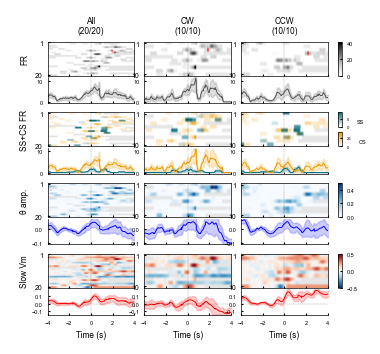

  [1/10] CKII_pAce21_PR_20250806 Cell 3
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell1_heatmap.svg


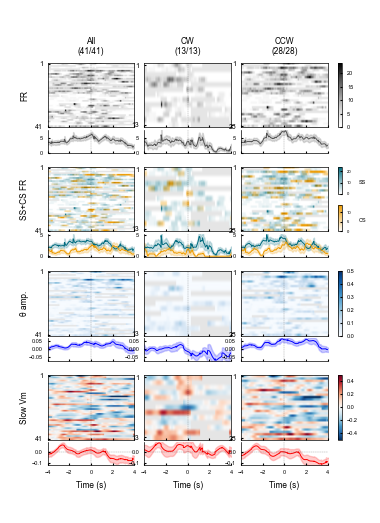

  [2/10] CKII_pAce38_PX_20251126 Cell 1
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell4_heatmap.svg


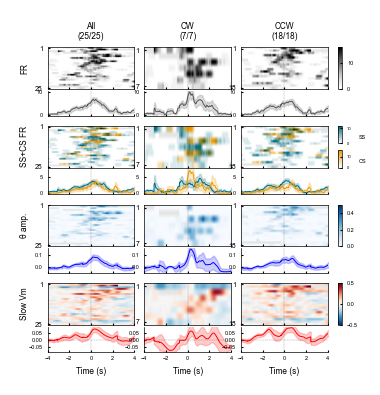

  [3/10] CKII_pAce38_PX_20251126 Cell 4
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell6_heatmap.svg


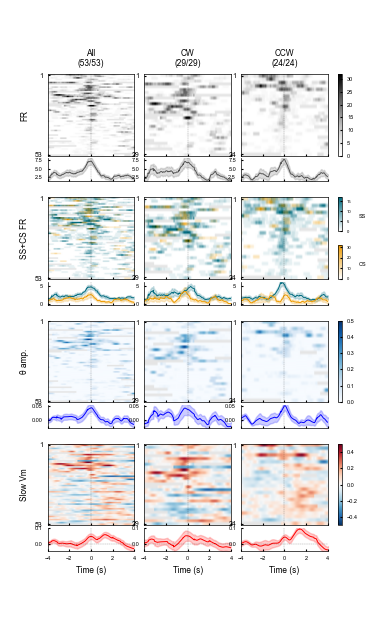

  [4/10] CKII_pAce38_PX_20251126 Cell 6
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell7_heatmap.svg


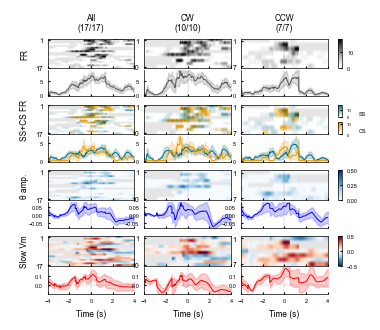

  [5/10] CKII_pAce38_PX_20251126 Cell 7
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce45_PX_20260118_Cell5_heatmap.svg


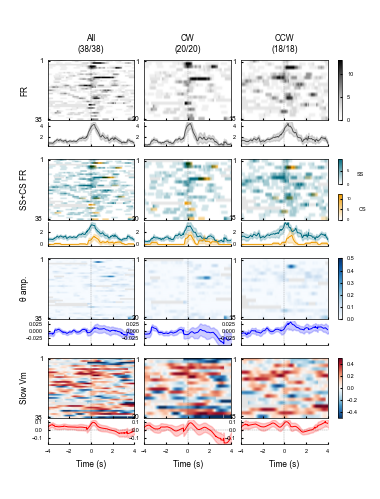

  [6/10] CKII_pAce45_PX_20260118 Cell 5
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce45_PX_20260118_Cell12_heatmap.svg


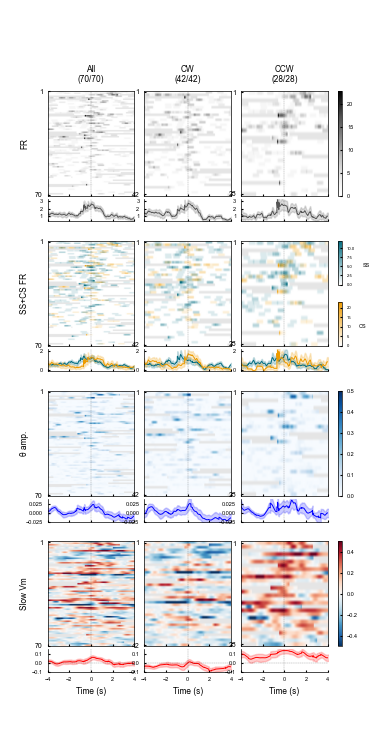

  [7/10] CKII_pAce45_PX_20260118 Cell 12
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce47_PX_20260128_Cell1_heatmap.svg


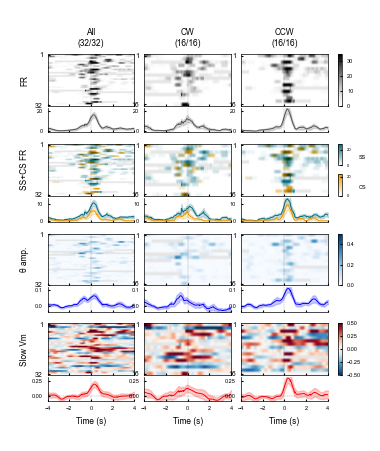

  [8/10] CKII_pAce47_PX_20260128 Cell 1
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce47_PX_20260128_Cell3_heatmap.svg


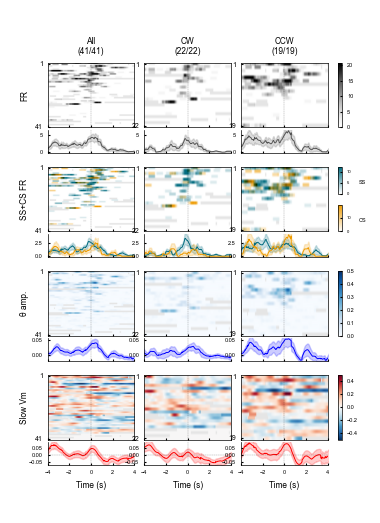

  [9/10] CKII_pAce47_PX_20260128 Cell 3
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps/CKII_pAce47_PX_20260128_Cell4_heatmap.svg


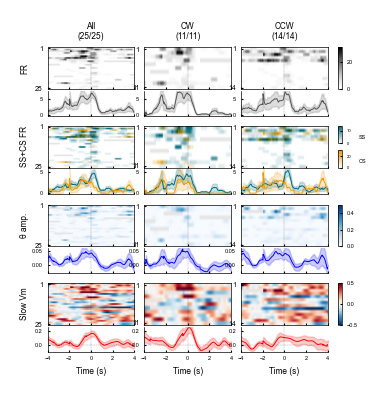

  [10/10] CKII_pAce47_PX_20260128 Cell 4

Saved individual CS+ PLC heatmaps to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps


In [6]:
# ===================== CS+ PLCs: Individual cell HEATMAP plots =====================
print(f"Plotting {len(cs_plus_entries)} CS+ PLCs individual cell heatmaps...")

trial_height = 0.02
cs_plus_heatmap_folder = os.path.join(figure_save_folder, 'pf_centered_CSplus_heatmaps')
# Clear old files before re-plotting
if os.path.exists(cs_plus_heatmap_folder):
    for f in os.listdir(cs_plus_heatmap_folder):
        os.remove(os.path.join(cs_plus_heatmap_folder, f))
os.makedirs(cs_plus_heatmap_folder, exist_ok=True)

for i, entry_data in enumerate(cs_plus_entries):
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    out_path = os.path.join(cs_plus_heatmap_folder, f'{session}_Cell{cell_idx+1}_heatmap.svg')
    
    plot_single_cell_heatmap(entry_data, time_rel_cs_plus, smooth_window=300, 
                              out_path=out_path, show_plot=True,
                              fr_vmax_scale=0.6, theta_vlim=(0, 0.5), slow_vlim=(-0.5, 0.5),
                              fig_width=3.8, trial_height=trial_height, xlim=xlim,
                              merge_ss_cs=MERGE_SS_CS,
                              merge_plateau=MERGE_PLATEAU,
                              plateau_vlim=PLATEAU_VLIM)
    print(f"  [{i+1}/{len(cs_plus_entries)}] {session} Cell {cell_idx+1}")

print(f"\nSaved individual CS+ PLC heatmaps to: {cs_plus_heatmap_folder}")

# Average plots for CS+ PLCs

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_average.svg


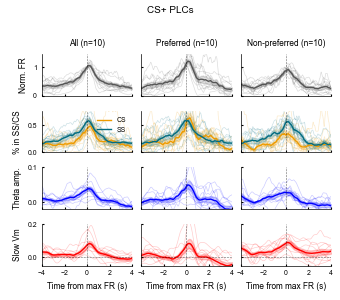

In [7]:
# ===================== CS+ PLCs: Pooled average (3-column: All/Preferred/Non-preferred) =====================
out_cs_plus = os.path.join(figure_save_folder, 'pf_centered_CSplus_average.svg')
plot_pooled_category_3col(time_rel_cs_plus, cs_plus_entries, 'CS+ PLCs', out_cs_plus,
                          smooth_window=400, plot_trials=PLOT_TRIALS,
                          trial_alpha=0.2, trial_linewidth=0.5,
                          theta_ylim=[-0.02,0.1], slow_ylim=[-0.05, 0.2],
                          figsize=(3.4, 3), xlim=xlim)


# Individual cell plots for CS- PLCs

In [8]:
# # ===================== CS- PLCs: Individual cell plots =====================
# print(f"Plotting {len(cs_minus_entries)} CS- PLCs individual cell plots...")

# cs_minus_save_folder = os.path.join(figure_save_folder, 'pf_centered_CSminus_individual')
# os.makedirs(cs_minus_save_folder, exist_ok=True)

# for i, entry_data in enumerate(cs_minus_entries):
#     session = entry_data['session']
#     cell_idx = entry_data['cell_idx']
#     out_path = os.path.join(cs_minus_save_folder, f'{session}_Cell{cell_idx+1}_pf_centered.svg')
    
#     plot_single_cell_3col(entry_data, time_rel_cs_minus, smooth_window=SMOOTH_WINDOW, plot_trials=PLOT_TRIALS,
#                           trial_alpha=TRIAL_ALPHA, trial_linewidth=TRIAL_LINEWIDTH, out_path=out_path, show_plot=True,
#                           theta_ylim=THETA_YLIM, slow_ylim=SLOW_YLIM,
#                           fr_ylim_scale=FR_YLIM_SCALE, ss_cs_ylim_scale=SS_CS_YLIM_SCALE)
#     print(f"  [{i+1}/{len(cs_minus_entries)}] {session} Cell {cell_idx+1}")

# print(f"\nSaved individual CS- PLC plots to: {cs_minus_save_folder}")

Plotting 5 CS- PLCs individual cell heatmaps...


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_85006/690702874.py:372: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce21_PR_20250806_Cell1_heatmap.svg


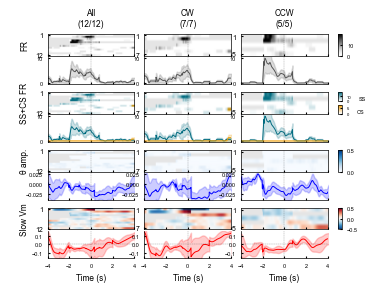

  [1/5] CKII_pAce21_PR_20250806 Cell 1
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce38_PX_20251126_Cell5_heatmap.svg


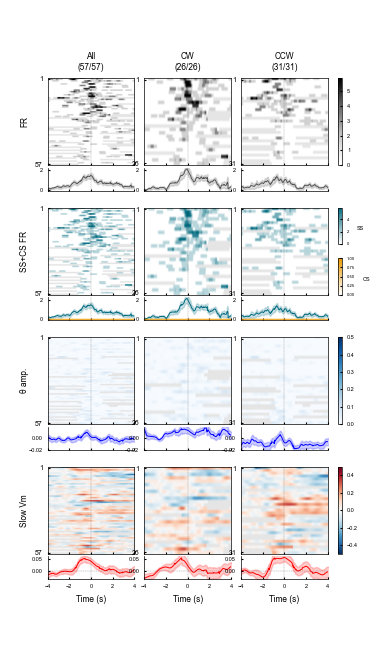

  [2/5] CKII_pAce38_PX_20251126 Cell 5
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce38_PX_20251126_Cell9_heatmap.svg


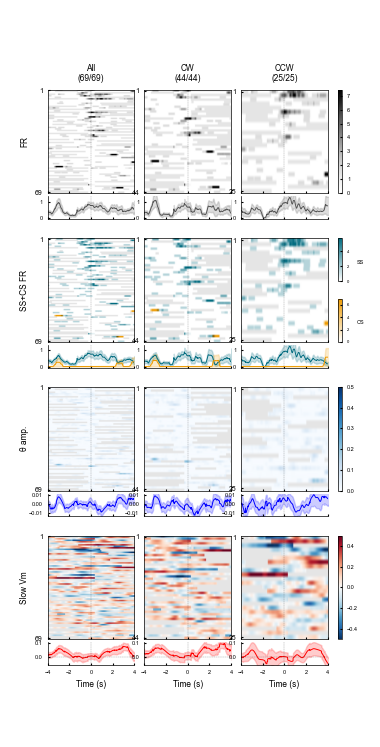

  [3/5] CKII_pAce38_PX_20251126 Cell 9
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce45_PX_20260118_Cell1_heatmap.svg


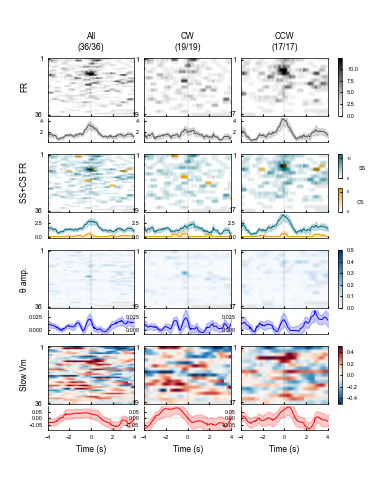

  [4/5] CKII_pAce45_PX_20260118 Cell 1
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_heatmaps/CKII_pAce45_PX_20260118_Cell3_heatmap.svg


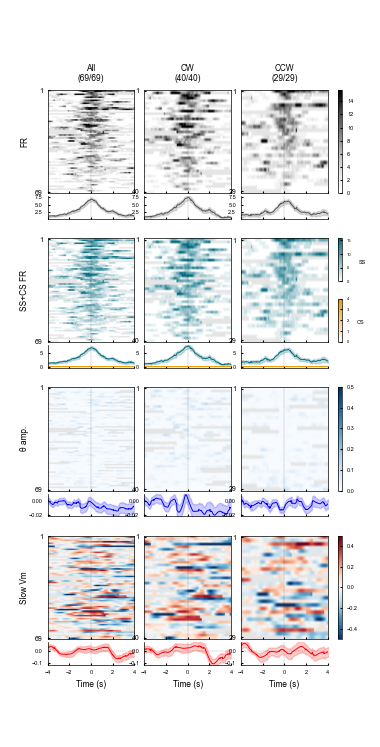

  [5/5] CKII_pAce45_PX_20260118 Cell 3

Saved individual CS- PLC heatmaps to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_heatmaps


In [9]:
# ===================== CS- PLCs: Individual cell HEATMAP plots =====================
print(f"Plotting {len(cs_minus_entries)} CS- PLCs individual cell heatmaps...")

cs_minus_heatmap_folder = os.path.join(figure_save_folder, 'pf_centered_CSminus_heatmaps')
# Clear old files before re-plotting
if os.path.exists(cs_minus_heatmap_folder):
    for f in os.listdir(cs_minus_heatmap_folder):
        os.remove(os.path.join(cs_minus_heatmap_folder, f))
os.makedirs(cs_minus_heatmap_folder, exist_ok=True)

for i, entry_data in enumerate(cs_minus_entries):
    session = entry_data['session']
    cell_idx = entry_data['cell_idx']
    out_path = os.path.join(cs_minus_heatmap_folder, f'{session}_Cell{cell_idx+1}_heatmap.svg')
    
    plot_single_cell_heatmap(entry_data, time_rel_cs_minus, smooth_window=300, 
                              out_path=out_path, show_plot=True,
                              fr_vmax_scale=0.6, theta_vlim=(0, 0.5), slow_vlim=(-0.5, 0.5),
                              fig_width=3.8, trial_height=trial_height, xlim=xlim,
                              merge_ss_cs=MERGE_SS_CS,
                              merge_plateau=MERGE_PLATEAU,
                              plateau_vlim=PLATEAU_VLIM,
                              avg_smooth_window=0)
    print(f"  [{i+1}/{len(cs_minus_entries)}] {session} Cell {cell_idx+1}")

print(f"\nSaved individual CS- PLC heatmaps to: {cs_minus_heatmap_folder}")

# Average plots for CS- PLCs

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_average.svg


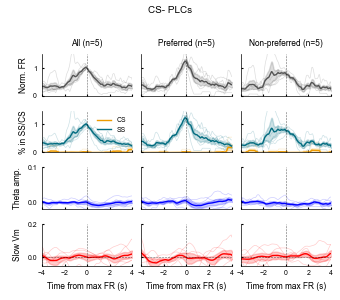

In [10]:
# ===================== CS- PLCs: Pooled average (3-column: All/Preferred/Non-preferred) =====================
out_cs_minus = os.path.join(figure_save_folder, 'pf_centered_CSminus_average.svg')
plot_pooled_category_3col(time_rel_cs_minus, cs_minus_entries, 'CS- PLCs', out_cs_minus,
                            smooth_window=400, plot_trials=PLOT_TRIALS,
                          trial_alpha=0.2, trial_linewidth=0.5,
                          theta_ylim=[-0.02,0.1], slow_ylim=[-0.05, 0.2],
                          figsize=(3.4, 3), xlim=xlim)


CS+ reliability data: 30 entries
CS- reliability data: 15 entries

CS+ PLCs - Spike counts per cell
n_trials/n_total shows reliability.

CKII_pAce21_PR_20250806 Cell 3:
           ALL: 20 traversals | All: 15/20 (75%) | SS: 11/20 (55%) | CS: 13/20 (65%)
     PREFERRED: 10 traversals | All:  6/10 (60%) | SS:  6/10 (60%) | CS:  4/10 (40%)
  NONPREFERRED: 10 traversals | All:  9/10 (90%) | SS:  5/10 (50%) | CS:  9/10 (90%)

CKII_pAce38_PX_20251126 Cell 1:
           ALL: 41 traversals | All: 41/41 (100%) | SS: 41/41 (100%) | CS: 31/41 (76%)
     PREFERRED: 28 traversals | All: 28/28 (100%) | SS: 28/28 (100%) | CS: 22/28 (79%)
  NONPREFERRED: 13 traversals | All: 13/13 (100%) | SS: 13/13 (100%) | CS:  9/13 (69%)

CKII_pAce38_PX_20251126 Cell 4:
           ALL: 25 traversals | All: 25/25 (100%) | SS: 25/25 (100%) | CS: 14/25 (56%)
     PREFERRED: 18 traversals | All: 18/18 (100%) | SS: 18/18 (100%) | CS:  9/18 (50%)
  NONPREFERRED:  7 traversals | All:  7/ 7 (100%) | SS:  7/ 7 (100%) | CS: 

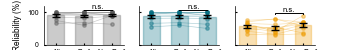

CS- All Spikes: paired t-test p=0.8407 (n.s.), n=5
CS- SS: paired t-test p=0.8407 (n.s.), n=5
CS- CS: Wilcoxon p=1.0000 (n.s.), n=5
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/reliability_CSminus.svg


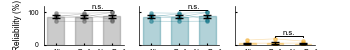

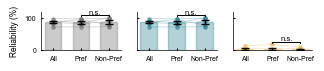

In [11]:
# ===================== Reliability Analysis =====================
# Calculate reliability (percentage of trials with non-zero spiking) for each cell

def calculate_reliability(time_rel, entries, category_name):
    """Calculate reliability for each cell and traversal type.
    
    Uses pre-computed reliability values from saved data:
    - All spikes: n_reliable_trials / n_total_trials (trials with ≥1 spike in PF)
    - SS: (trials with SS spikes in PF) / n_total_trials
    - CS: (trials with CS spikes in PF) / n_total_trials
    
    Spike counts are from trial_data which counts spikes WITHIN the place field traversal.
    Directions: 'all', 'preferred', 'nonpreferred' (preferred = higher rate at PF center).
    """
    results = []
    zero_idx = int(np.argmin(np.abs(time_rel))) if time_rel is not None and len(time_rel) > 0 else 0
    
    for entry_data in entries:
        session = entry_data['session']
        cell_idx = entry_data['cell_idx']
        cell_data = entry_data.get('data')
        
        if cell_data is None:
            continue
        
        # Determine preferred direction (same logic as plot_pooled_category_3col)
        cw_rm = np.asarray(cell_data.get('cw', {}).get('rate_mean', []), dtype=float)
        ccw_rm = np.asarray(cell_data.get('ccw', {}).get('rate_mean', []), dtype=float)
        preferred_dir = None
        if len(cw_rm) > zero_idx and len(ccw_rm) > zero_idx:
            cw_zero = cw_rm[zero_idx]
            ccw_zero = ccw_rm[zero_idx]
            if np.isfinite(cw_zero) and np.isfinite(ccw_zero):
                if cw_zero > ccw_zero:
                    preferred_dir = 'cw'
                elif ccw_zero > cw_zero:
                    preferred_dir = 'ccw'
        
        for direction in ['all', 'preferred', 'nonpreferred']:
            if direction == 'preferred':
                if preferred_dir is None:
                    continue
                dir_data = cell_data.get(preferred_dir, {})
            elif direction == 'nonpreferred':
                if preferred_dir is None:
                    continue
                nonpref = 'ccw' if preferred_dir == 'cw' else 'cw'
                dir_data = cell_data.get(nonpref, {})
            else:
                dir_data = cell_data.get(direction, {})
            
            if not dir_data:
                continue
            
            n_trials = dir_data.get('n_trials', 0)
            n_total_trials = dir_data.get('n_total_trials', 0)
            
            if n_total_trials == 0:
                continue
            
            # Use pre-computed reliability for all spikes
            n_reliable = dir_data.get('n_reliable_trials', n_trials)
            rel_all = dir_data.get('reliability', n_reliable / n_total_trials if n_total_trials > 0 else 0)
            rel_all = rel_all * 100  # Convert to percentage
            
            # Get trial_data for SS/CS spike counts within PF
            trial_data = dir_data.get('trial_data', {})
            n_spikes_ss = trial_data.get('n_spikes_ss', None)
            n_spikes_cs = trial_data.get('n_spikes_cs', None)
            
            # SS reliability: count trials with ≥1 SS spike in PF
            if n_spikes_ss is not None:
                n_spikes_ss = np.asarray(n_spikes_ss)
                n_with_ss = int(np.sum(n_spikes_ss > 0))
                rel_ss = (n_with_ss / n_total_trials) * 100
            else:
                n_with_ss = 0
                rel_ss = 0.0
            
            # CS reliability: count trials with ≥1 CS spike in PF
            if n_spikes_cs is not None:
                n_spikes_cs = np.asarray(n_spikes_cs)
                n_with_cs = int(np.sum(n_spikes_cs > 0))
                rel_cs = (n_with_cs / n_total_trials) * 100
            else:
                n_with_cs = 0
                rel_cs = 0.0
            
            results.append({
                'session': session,
                'cell_idx': cell_idx,
                'category': category_name,
                'direction': direction,
                'reliability_all': rel_all,
                'reliability_ss': rel_ss,
                'reliability_cs': rel_cs,
                'n_reliable_trials': n_reliable,
                'n_with_ss': n_with_ss,
                'n_with_cs': n_with_cs,
                'n_trials': n_trials,
                'n_total_trials': n_total_trials,
            })
    
    return pd.DataFrame(results)

# Calculate reliability for CS+ and CS- PLCs
df_rel_csplus = calculate_reliability(time_rel_cs_plus, cs_plus_entries, 'CS+')
df_rel_csminus = calculate_reliability(time_rel_cs_minus, cs_minus_entries, 'CS-')

print(f"CS+ reliability data: {len(df_rel_csplus)} entries")
print(f"CS- reliability data: {len(df_rel_csminus)} entries")

# ===================== Print detailed spike counts per cell =====================
def print_spike_counts(time_rel, entries, category_name):
    """Print detailed spike counts for each cell."""
    print(f"\n{'='*80}")
    print(f"{category_name} PLCs - Spike counts per cell")
    print(f"n_trials/n_total shows reliability.")
    print(f"{'='*80}")
    
    zero_idx = int(np.argmin(np.abs(time_rel))) if time_rel is not None and len(time_rel) > 0 else 0
    
    for entry_data in entries:
        session = entry_data['session']
        cell_idx = entry_data['cell_idx']
        cell_data = entry_data.get('data')
        
        if cell_data is None:
            print(f"{session} Cell {cell_idx+1}: No data")
            continue
        
        print(f"\n{session} Cell {cell_idx+1}:")
        
        # Determine preferred direction
        cw_rm = np.asarray(cell_data.get('cw', {}).get('rate_mean', []), dtype=float)
        ccw_rm = np.asarray(cell_data.get('ccw', {}).get('rate_mean', []), dtype=float)
        preferred_dir = None
        if len(cw_rm) > zero_idx and len(ccw_rm) > zero_idx:
            cw_zero = cw_rm[zero_idx]
            ccw_zero = ccw_rm[zero_idx]
            if np.isfinite(cw_zero) and np.isfinite(ccw_zero):
                if cw_zero > ccw_zero:
                    preferred_dir = 'cw'
                elif ccw_zero > cw_zero:
                    preferred_dir = 'ccw'
        
        dir_map = {'all': 'all'}
        if preferred_dir is not None:
            dir_map['preferred'] = preferred_dir
            dir_map['nonpreferred'] = 'ccw' if preferred_dir == 'cw' else 'cw'
        
        for direction, data_key in dir_map.items():
            dir_data = cell_data.get(data_key, {})
            
            if not dir_data:
                print(f"  {direction.upper():>12}: No data")
                continue
            
            n_trials = dir_data.get('n_trials', 0)
            n_total = dir_data.get('n_total_trials', 0)
            
            if n_total == 0:
                print(f"  {direction.upper():>12}: No traversals")
                continue
            
            # Use pre-computed reliability and spike counts from trial_data
            n_reliable = dir_data.get('n_reliable_trials', n_trials)
            trial_data = dir_data.get('trial_data', {})
            n_spikes_ss = trial_data.get('n_spikes_ss', None)
            n_spikes_cs = trial_data.get('n_spikes_cs', None)
            
            n_with_ss = int(np.sum(np.asarray(n_spikes_ss) > 0)) if n_spikes_ss is not None else 0
            n_with_cs = int(np.sum(np.asarray(n_spikes_cs) > 0)) if n_spikes_cs is not None else 0
            
            rel_all = 100 * n_reliable / n_total if n_total > 0 else 0
            rel_ss = 100 * n_with_ss / n_total if n_total > 0 else 0
            rel_cs = 100 * n_with_cs / n_total if n_total > 0 else 0
            
            print(f"  {direction.upper():>12}: {n_total:2d} traversals | "
                  f"All: {n_reliable:2d}/{n_total:2d} ({rel_all:.0f}%) | "
                  f"SS: {n_with_ss:2d}/{n_total:2d} ({rel_ss:.0f}%) | "
                  f"CS: {n_with_cs:2d}/{n_total:2d} ({rel_cs:.0f}%)")

print_spike_counts(time_rel_cs_plus, cs_plus_entries, 'CS+')
print_spike_counts(time_rel_cs_minus, cs_minus_entries, 'CS-')

# ===================== Plot Reliability =====================
from scipy import stats as _scipy_stats

def _pval_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

def _paired_test(a, b):
    """Run Shapiro-Wilk on the differences; use paired t-test if normal, Wilcoxon otherwise.
    Returns (p_value, test_name).
    """
    diffs = np.array(a) - np.array(b)
    _, shapiro_p = _scipy_stats.shapiro(diffs)
    if shapiro_p > 0.05:
        # Differences are normal → paired t-test
        _, p_val = _scipy_stats.ttest_rel(a, b)
        test_name = 'paired t-test'
    else:
        # Non-normal → Wilcoxon signed-rank
        _, p_val = _scipy_stats.wilcoxon(a, b)
        test_name = 'Wilcoxon'
    return p_val, test_name

def plot_reliability_scatter_bar(df_rel, category_name, out_path=None):
    """Plot reliability: scatter for each cell connected by lines, with bar plot overlay.
    Normality of pairwise differences tested with Shapiro-Wilk; paired t-test if normal,
    Wilcoxon signed-rank otherwise. Bracket + significance shown between Pref and Non-Pref.
    """
    
    if len(df_rel) == 0:
        print(f"No data for {category_name}")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(3.5, 0.5), sharey=True)
    
    spike_types = ['all', 'ss', 'cs']
    spike_labels = ['All Spikes', 'SS', 'CS']
    spike_colors = ['#555555', '#026C80', '#EE9B00']
    
    directions = ['all', 'preferred', 'nonpreferred']
    dir_labels = ['All', 'Pref', 'Non-Pref']
    x_positions = np.array([0, 1, 2])
    
    for ax_idx, (spike_type, spike_label, spike_color) in enumerate(zip(spike_types, spike_labels, spike_colors)):
        ax = axes[ax_idx]
        
        # Get unique cells
        cell_ids = df_rel[['session', 'cell_idx']].drop_duplicates()
        
        # Collect data for bar plot
        all_values = {d: [] for d in directions}
        
        # Plot individual cells
        for _, cell_row in cell_ids.iterrows():
            cell_data = df_rel[(df_rel['session'] == cell_row['session']) & 
                               (df_rel['cell_idx'] == cell_row['cell_idx'])]
            
            y_vals = []
            x_vals = []
            for i, direction in enumerate(directions):
                dir_data = cell_data[cell_data['direction'] == direction]
                if len(dir_data) > 0:
                    val = dir_data[f'reliability_{spike_type}'].values[0]
                    if not np.isnan(val):
                        y_vals.append(val)
                        x_vals.append(x_positions[i])
                        all_values[direction].append(val)
            
            # Plot scatter and connecting lines
            if len(x_vals) > 0:
                ax.scatter(x_vals, y_vals, color=spike_color, s=6, alpha=0.4, zorder=2)
                if len(x_vals) > 1:
                    ax.plot(x_vals, y_vals, color=spike_color, linewidth=0.5, alpha=0.3, zorder=1)
        
        # Calculate means and SEMs for bar plot
        means = []
        sems = []
        for direction in directions:
            vals = np.array(all_values[direction])
            if len(vals) > 0:
                means.append(np.nanmean(vals))
                sems.append(np.nanstd(vals) / np.sqrt(len(vals)))
            else:
                means.append(0)
                sems.append(0)
        
        # Plot bar with error bars
        ax.bar(x_positions, means, width=0.6, color=spike_color, alpha=0.3, edgecolor=spike_color, linewidth=1, zorder=0)
        ax.errorbar(x_positions, means, yerr=sems, fmt='none', color='black', capsize=3, linewidth=1, zorder=3)
        
        # ---- Paired test: Preferred vs Non-preferred ----
        paired_pref = []
        paired_nonpref = []
        for _, cell_row in cell_ids.iterrows():
            cell_vals = df_rel[(df_rel['session'] == cell_row['session']) &
                               (df_rel['cell_idx'] == cell_row['cell_idx'])]
            pref_row = cell_vals[cell_vals['direction'] == 'preferred']
            nonpref_row = cell_vals[cell_vals['direction'] == 'nonpreferred']
            if len(pref_row) > 0 and len(nonpref_row) > 0:
                pv = pref_row[f'reliability_{spike_type}'].values[0]
                npv = nonpref_row[f'reliability_{spike_type}'].values[0]
                if not (np.isnan(pv) or np.isnan(npv)):
                    paired_pref.append(pv)
                    paired_nonpref.append(npv)
        
        if len(paired_pref) >= 3:
            try:
                p_val, test_name = _paired_test(paired_pref, paired_nonpref)
            except Exception:
                p_val, test_name = 1.0, 'error'
            sig_text = _pval_to_stars(p_val)
            print(f"{category_name} {spike_label}: {test_name} p={p_val:.4f} ({sig_text}), n={len(paired_pref)}")
            
            # Place bracket above the highest actual data point in pref/nonpref
            pref_max = max(all_values['preferred']) if all_values['preferred'] else 0
            nonpref_max = max(all_values['nonpreferred']) if all_values['nonpreferred'] else 0
            bracket_y = max(pref_max, nonpref_max) + 8
            tick_h = 2
            ax.plot([1, 1, 2, 2],
                    [bracket_y - tick_h, bracket_y, bracket_y, bracket_y - tick_h],
                    color='black', linewidth=0.7, clip_on=False)
            ax.text(1.5, bracket_y + 0.5, sig_text,
                    ha='center', va='bottom', fontsize=5.5, clip_on=False)
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(dir_labels, fontsize=5)
        ax.set_ylim(0, 120)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    axes[0].set_ylabel('Reliability (%)', fontsize=6)
    
    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f'Saved: {out_path}')
    
    plt.show()
    return fig

# Plot for CS+ PLCs
out_rel_csplus = os.path.join(figure_save_folder, 'reliability_CSplus.svg')
plot_reliability_scatter_bar(df_rel_csplus, 'CS+', out_rel_csplus)

# Plot for CS- PLCs
out_rel_csminus = os.path.join(figure_save_folder, 'reliability_CSminus.svg')
plot_reliability_scatter_bar(df_rel_csminus, 'CS-', out_rel_csminus)